In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
load_dotenv()

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: Annotated[str , Field(..., description="What to cover")]

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [5]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [6]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke([SystemMessage(content=("Create a blog plan with 5-7 sections on the following topic.")),HumanMessage(content=f"Topic: {state['topic']}"),])
    return {"plan": plan}

In [7]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})for task in state["plan"].tasks]

In [8]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [20]:
from pathlib import Path
import re

def reducer(state: State) -> dict:

    print("=" * 50)
    print("Reducer called!")

    print("State:")
    print(state)

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    print("Title:", title)
    print("Body:", body)

    final_md = f"# {title}\n\n{body}\n"

    print("Final Markdown:")
    print(final_md)

    # ✅ FIX: sanitize title to remove Windows-illegal characters before using as filename
    safe_title = re.sub(r'[\\/:*?"<>|]', '', title)
    filename = safe_title.lower().replace(" ", "_") + ".md"

    print("Saving to:", filename)

    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [21]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

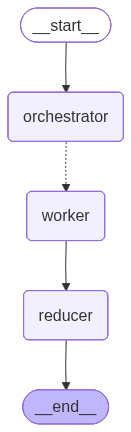

In [22]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [23]:
out = app.invoke({"topic": "Write a blog on Self Motivation", "sections": []})

Reducer called!
State:
{'topic': 'Write a blog on Self Motivation', 'plan': Plan(blog_title='Unlocking Your Potential: A Guide to Self Motivation', tasks=[Task(id=1, title='Introduction to Self Motivation', brief='Define self motivation and explain its importance in personal and professional life.'), Task(id=2, title='Understanding the Psychology Behind Self Motivation', brief='Discuss the psychological factors that drive self motivation, including intrinsic and extrinsic motivators.'), Task(id=3, title='Techniques to Cultivate Self Motivation', brief='Provide actionable tips and strategies to develop and enhance self motivation, such as setting goals, positive affirmations, and creating routines.'), Task(id=4, title='Overcoming Common Obstacles to Self Motivation', brief='Identify common challenges people face that hinder self motivation and suggest ways to overcome them.'), Task(id=5, title='The Role of Environment and Support Systems', brief='Explore how surroundings and social supp

In [13]:
from pathlib import Path

print(Path.cwd())

d:\Blog Writing Agent\blog-writing-agent


In [14]:
from pathlib import Path

for file in Path.cwd().iterdir():
    print(file.name)

.env
.git
1_bwa_basic.ipynb
2_bwa_improved_prompting.ipynb
3_bwa_research.ipynb
4_bwa_research_fine_tuned.ipynb
5_bwa_image.ipynb
bwa_backend.py
bwa_frontend.py
tavily_test.ipynb
understanding_self-attention
understanding_self-attention.md


In [15]:
from pathlib import Path

file = Path("understanding_self_attention")

print(file.exists())
print(file.read_text(encoding="utf-8"))

False


FileNotFoundError: [Errno 2] No such file or directory: 'understanding_self_attention'